In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# Imports & Global Config
# ═══════════════════════════════════════════════════════════════════════════
"""
Global configuration. All hyperparameters are defined once here and
referenced throughout — no magic numbers elsewhere in the notebook.

N_PROMPTS   = 500  → proposal §3.4
DETECT_NSTD = 2.0  → Zhang & Nanda (2023) exact threshold, proposal §3.2
GN_STD_MULT = 3.0  → Zhang & Nanda noise scaling
MIN_DELTA   = 1.0  → minimum acceptable (clean - corrupted) LD before
                     running patching; values below this suggest the
                     corruption is not working and results would be
                     meaningless (pre-flight guard in Cell 10)
"""
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from functools import partial
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings("ignore")

from transformer_lens import HookedTransformer

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Device & HuggingFace cache ─────────────────────────────────────────────
os.environ["HF_HOME"] = f"/scratch/{os.environ['USER']}/.cache/huggingface"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Experiment parameters ──────────────────────────────────────────────────
N_PROMPTS    = 500
DETECT_NSTD  = 2.0
GN_STD_MULT  = 3.0
MIN_DELTA    = 1.0   # pre-flight guard: abort condition if delta < this

# ── Checkpointing ──────────────────────────────────────────────────────────
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Sanity check: environment ──────────────────────────────────────────────
print("── Environment ──────────────────────────────────────────")
assert torch.cuda.is_available(), (
    "CUDA not available — relaunch session with gpu-interactive partition "
    "and cuda/12.8.0 module"
)
print(f"  Device:      {DEVICE}")
print(f"  GPU:         {torch.cuda.get_device_name(0)}")
print(f"  VRAM total:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  VRAM free:   {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")
print(f"  PyTorch:     {torch.__version__}")
print(f"  HF_HOME:     {os.environ['HF_HOME']}")
assert os.path.exists("/scratch"), "Scratch filesystem not mounted"
print(f"  Checkpoints: {CHECKPOINT_DIR}/")
print("✓ Environment check passed\n")

── Environment ──────────────────────────────────────────
  Device:      cuda
  GPU:         NVIDIA A100-SXM4-80GB
  VRAM total:  85.1 GB
  VRAM free:   78.3 GB
  PyTorch:     2.8.0+cu128
  HF_HOME:     /scratch/koppisetty.e/.cache/huggingface
  Checkpoints: checkpoints/
✓ Environment check passed



# Patching Under Pressure
## Stress-Testing Causal Interpretability Across Experimental Choices
**CS7180 Actionable Interpretability Methods | Easha Meher Koppisetty**

### Overview
This notebook implements the experimental pipeline for *Patching Under Pressure*,
which extends Zhang & Nanda (2023)'s systematic sensitivity analysis of activation
patching to four methodological choices:

1. **Patching direction** — denoising (sufficiency) vs. noising (necessity)
2. **Corruption method** — STR vs. Gaussian noise (replication of Zhang & Nanda)
3. **Prompt template** — ABBA vs. ABAB word order
4. **Token corrupted** — S2 vs. S1+IO

**Model:** Pythia-1.4B via TransformerLens  
**Task:** Indirect Object Identification (IOI)  
**Metric:** Mean logit difference (IO logit − S logit) at final query position  
**Detection:** 2-SD threshold following Zhang & Nanda (2023) exactly

### Hypotheses
| Axis | Hypothesis |
|------|-----------|
| Direction | Denoising and noising will disagree — denoising finds sufficient late-layer heads (name movers); noising finds necessary early-layer heads (duplicate token, induction) |
| Template | Minor differences concentrated in position-sensitive heads (duplicate token, S-inhibition) |
| Token Corrupted | Large differences — S2 corruption misses name movers; S1+IO finds them (consistent with Zhang & Nanda appendix) |
| GN vs STR | Inconsistency replicates from Zhang & Nanda on Pythia-1.4B |

### Circuit Detection Levels
- **(a) Strict:** exact (layer, head) set match
- **(b) Relaxed:** component-type detection score n/total ← primary reporting grain
- **(c) Graded:** Jaccard similarity between detected head sets

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2 — IOI Dataset
# ═══════════════════════════════════════════════════════════════════════════
"""
Self-contained IOI dataset. Replaces transformer_lens.ioi_dataset
(removed in TransformerLens >= 2.0).

Design decisions:
  1. Single-token names only — guarantees each name occupies exactly
     one position, making word_idx unambiguous.
  2. Right-padding explicitly set before batch tokenization — preserves
     left-to-right position indices so word_idx correctly indexes toks.
  3. Positions computed from self.toks (the batch output), not from
     individual tokenizer.encode() calls — accounts for any BOS token
     prepended by add_special_tokens.
  4. "restaurant" excluded from PLACES — it tokenizes to 2 tokens in
     Pythia's tokenizer, causing variable sequence lengths which would
     make padding positions shift across prompts.
  5. Assertion in _build checks S appears exactly twice — catches any
     tokenization edge cases where a name token collides with another
     word token.

Sanity checks (verify_dataset):
  - Token at IO position matches io_tokenIDs[i]
  - Token at S1/S2 positions matches s_tokenIDs[i]
  - S1 < S2 for every prompt
  - IO != S1 and IO != S2 for every prompt
  - end position points to a non-padding token
  - All position indices are within [0, seq_len)
"""
NAMES = [
    "Aaron", "Adam", "Alice", "Amy", "Andrew", "Anna", "Bob",
    "Brian", "Carol", "Charlie", "Chris", "Claire", "David",
    "Diana", "Edward", "Emily", "Emma", "Eric", "Frank", "George",
    "Grace", "Hannah", "Henry", "Jack", "James", "Jane", "Jason",
    "Jennifer", "John", "Julia", "Kate", "Kevin", "Laura", "Linda",
    "Lisa", "Luke", "Mark", "Mary", "Michael", "Nancy", "Oliver",
    "Paul", "Peter", "Rachel", "Robert", "Ryan", "Sarah", "Tom",
]
# "restaurant" excluded: tokenizes to >1 token → variable seq lengths
PLACES  = ["store", "park", "school", "office", "bank", "market"]
OBJECTS = ["drink", "gift", "book", "ball", "bag", "pen", "note"]


class IOIDataset:
    """
    IOI prompt dataset for Pythia-1.4B.

    Generates:
      ABBA: "When {io_name} and {s_name} went to the {place},
             {s_name} gave a {obj} to"   → predict io_name
      ABAB: "When {s_name} and {io_name} went to the {place},
             {s_name} gave a {obj} to"   → predict io_name

    In both templates the subject S gives the object, so the model
    should predict the indirect object IO at the blank.

    Attributes:
        toks         [N, seq_len] right-padded token tensor
        io_tokenIDs  list[int]    IO name token ID per prompt
        s_tokenIDs   list[int]    S name token ID per prompt
        word_idx     dict         IO/S1/S2/end → [N] position tensors
                                  All positions index into self.toks.
    """

    def __init__(self, prompt_type: str, N: int, tokenizer,
                 prepend_bos: bool = True, seed: int = SEED):
        random.seed(seed)
        np.random.seed(seed)
        self.prompt_type = prompt_type
        self.tokenizer   = tokenizer
        self.prepend_bos = prepend_bos
        self._seed       = seed

        # Filter to names tokenizing to exactly one token (with leading space)
        self.valid_names = [
            n for n in NAMES if len(tokenizer.encode(" " + n)) == 1
        ]
        assert len(self.valid_names) >= 3, (
            f"Only {len(self.valid_names)} single-token names found — "
            "need at least 3"
        )
        self._build(N)

    def _build(self, N: int):
        prompts = []
        io_ids  = []
        s_ids   = []

        for _ in range(N):
            io_name, s_name, _ = random.sample(self.valid_names, 3)
            place = random.choice(PLACES)
            obj   = random.choice(OBJECTS)

            if self.prompt_type == "ABBA":
                # IO appears first, S appears second and third
                text = (f"When {io_name} and {s_name} went to the {place}, "
                        f"{s_name} gave a {obj} to")
            else:  # ABAB
                # S appears first and third, IO appears second
                text = (f"When {s_name} and {io_name} went to the {place}, "
                        f"{s_name} gave a {obj} to")

            prompts.append(text)
            io_ids.append(self.tokenizer.encode(" " + io_name)[0])
            s_ids.append( self.tokenizer.encode(" " + s_name)[0])

        # Batch tokenize with explicit right-padding
        # Right-padding preserves left-to-right position indices.
        orig_side                   = self.tokenizer.padding_side
        self.tokenizer.padding_side = "right"
        encoded = self.tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            add_special_tokens=self.prepend_bos,
        )
        self.tokenizer.padding_side = orig_side   # restore
        self.toks = encoded["input_ids"]          # [N, seq_len]

        # Compute positions from batch-tokenized output, not encode()
        # This correctly accounts for any BOS prepended by the tokenizer.
        io_pos, s1_pos, s2_pos, end_pos = [], [], [], []
        pad_id = self.tokenizer.pad_token_id or 0

        for i in range(N):
            toks_i = self.toks[i].tolist()
            io_tok = io_ids[i]
            s_tok  = s_ids[i]

            # IO: appears exactly once in each prompt
            assert io_tok in toks_i, (
                f"IO token {io_tok} not found in prompt {i}: "
                f"{self.tokenizer.decode(toks_i)}"
            )
            io_pos.append(toks_i.index(io_tok))

            # S: must appear exactly twice (S1 and S2)
            s_all = [j for j, t in enumerate(toks_i) if t == s_tok]
            assert len(s_all) == 2, (
                f"Expected 2 S occurrences in prompt {i}, found {len(s_all)}: "
                f"{self.tokenizer.decode(toks_i)}"
            )
            s1_pos.append(s_all[0])
            s2_pos.append(s_all[1])

            # End: last non-padding token
            end = len(toks_i) - 1
            while end > 0 and toks_i[end] == pad_id:
                end -= 1
            end_pos.append(end)

        self.io_tokenIDs = io_ids
        self.s_tokenIDs  = s_ids
        self.word_idx    = {
            "IO":  torch.tensor(io_pos),
            "S1":  torch.tensor(s1_pos),
            "S2":  torch.tensor(s2_pos),
            "end": torch.tensor(end_pos),
        }

    def __len__(self) -> int:
        return len(self.io_tokenIDs)


def verify_dataset(ds: IOIDataset, name: str = "dataset") -> None:
    """
    Comprehensive dataset sanity checks.
    Verifies that every position in word_idx correctly indexes into toks.
    Aborts with a descriptive error if anything is wrong.
    """
    print(f"── Verifying {name} ────────────────────────────────────")
    N       = len(ds)
    seq_len = ds.toks.shape[1]

    # 1. Shape consistency
    assert ds.toks.shape[0] == N, "toks batch size != len(dataset)"
    for key, pos in ds.word_idx.items():
        assert pos.shape[0] == N, f"word_idx[{key}] length != N"
        assert (pos >= 0).all(),       f"word_idx[{key}] has negative positions"
        assert (pos < seq_len).all(),  f"word_idx[{key}] has out-of-bounds positions"

    # 2. S1 < S2 for all prompts (S1 always precedes S2 in both templates)
    assert (ds.word_idx["S1"] < ds.word_idx["S2"]).all(), \
        "S1 should come before S2 in every prompt"

    # 3. IO != S1 and IO != S2 (IO and S are different people at different positions)
    assert (ds.word_idx["IO"] != ds.word_idx["S1"]).all(), \
        "IO and S1 at the same position in some prompt"
    assert (ds.word_idx["IO"] != ds.word_idx["S2"]).all(), \
        "IO and S2 at the same position in some prompt"

    # 4. end position holds a non-padding token
    pad_id = ds.tokenizer.pad_token_id or 0
    for i in range(N):
        end_tok = ds.toks[i, ds.word_idx["end"][i]].item()
        assert end_tok != pad_id, \
            f"end position {ds.word_idx['end'][i].item()} is a padding token in prompt {i}"

    # 5. Token at each named position matches the expected name token ID
    for i in range(N):
        io_p  = ds.word_idx["IO"][i].item()
        s1_p  = ds.word_idx["S1"][i].item()
        s2_p  = ds.word_idx["S2"][i].item()
        io_id = ds.io_tokenIDs[i]
        s_id  = ds.s_tokenIDs[i]

        actual_io = ds.toks[i, io_p].item()
        actual_s1 = ds.toks[i, s1_p].item()
        actual_s2 = ds.toks[i, s2_p].item()

        assert actual_io == io_id, (
            f"Prompt {i}: token at IO position {io_p} is "
            f"{ds.tokenizer.decode([actual_io])!r}, expected "
            f"{ds.tokenizer.decode([io_id])!r}"
        )
        assert actual_s1 == s_id, (
            f"Prompt {i}: token at S1 position {s1_p} is "
            f"{ds.tokenizer.decode([actual_s1])!r}, expected "
            f"{ds.tokenizer.decode([s_id])!r}"
        )
        assert actual_s2 == s_id, (
            f"Prompt {i}: token at S2 position {s2_p} is "
            f"{ds.tokenizer.decode([actual_s2])!r}, expected "
            f"{ds.tokenizer.decode([s_id])!r}"
        )

    # 6. Print decoded examples for human inspection
    print(f"  N={N}, seq_len={seq_len}, template={ds.prompt_type}")
    for i in range(min(3, N)):
        decoded = ds.tokenizer.decode(ds.toks[i])
        print(f"  [{i}] {decoded!r}")
        print(f"       IO@{ds.word_idx['IO'][i].item()} "
              f"S1@{ds.word_idx['S1'][i].item()} "
              f"S2@{ds.word_idx['S2'][i].item()} "
              f"end@{ds.word_idx['end'][i].item()}")

    print(f"✓ {name}: all {N} prompts verified\n")


print("IOIDataset class defined ✓")


IOIDataset class defined ✓


In [14]:
"""
Cell 3: Load Pythia-1.4B via TransformerLens.

From proposal §3.1:
  "Pythia-1.4B via TransformerLens. Pythia is a different model suite
   from Zhang & Nanda's GPT-2 and GPT-J, providing a test of whether
   their findings generalize across architectures."

Note: refactor_factored_attn_matrices is excluded because Pythia uses
rotary position embeddings (RoPE), which make the QK factorization
position-dependent and therefore incompatible with this option.
"""
print("Loading Pythia-1.4B via TransformerLens …")
model = HookedTransformer.from_pretrained(
    "EleutherAI/pythia-1.4b",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
    device=DEVICE,
)
model.eval()

N_LAYERS = model.cfg.n_layers   # 24
N_HEADS  = model.cfg.n_heads    # 16
D_MODEL  = model.cfg.d_model    # 2048
print(f"Architecture: {N_LAYERS} layers × {N_HEADS} heads × d_model={D_MODEL}")
print(f"Position embedding type: {model.cfg.positional_embedding_type}")

Loading Pythia-1.4B via TransformerLens …
Loaded pretrained model EleutherAI/pythia-1.4b into HookedTransformer
Architecture: 24 layers × 16 heads × d_model=2048
Position embedding type: rotary


In [15]:
"""
Cell 4: Known IOI circuit components for Pythia-1.4B.

Component types follow Wang et al. (2022) and Hanna et al. (2024):
  - Name Mover heads:      late layers, attend to IO, copy name to output
  - S-Inhibition heads:    mid layers, suppress subject token
  - Duplicate Token heads: early layers, detect repeated tokens
  - Induction heads:       early-mid layers, in-context pattern matching

Head indices derived empirically from Condition 1 (reproduction baseline,
denoising | ABBA | S2 | STR), cross-referenced with layer-depth priors
from the IOI circuit literature. These are used for relaxed detection
scoring (proposal §3.2, level b).

Detection is reported at three levels (proposal §3.2):
  (a) Strict:  exact (layer, head) set equality
  (b) Relaxed: component-type score n_detected/total  ← primary
  (c) Graded:  Jaccard similarity between detected sets
"""
KNOWN_CIRCUIT = {
    "Name Mover":      [(22, 2), (21, 3), (17, 0)],
    "S-Inhibition":    [(10, 7), (15, 15), (11, 8)],
    "Duplicate Token": [(4, 5),  (4, 7)],
    "Induction":       [(7, 15), (7, 6)],
}

COMP_COLORS = {
    "Name Mover":      "yellow",
    "S-Inhibition":    "lime",
    "Duplicate Token": "cyan",
    "Induction":       "orange",
}

print("Known circuit components:")
for comp, heads in KNOWN_CIRCUIT.items():
    print(f"  {comp:<20}: {heads}")

Known circuit components:
  Name Mover          : [(22, 2), (21, 3), (17, 0)]
  S-Inhibition        : [(10, 7), (15, 15), (11, 8)]
  Duplicate Token     : [(4, 5), (4, 7)]
  Induction           : [(7, 15), (7, 6)]


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — Metric & Dataset Cache
# ═══════════════════════════════════════════════════════════════════════════
"""
Mean logit difference metric and dataset cache (proposal §3.2).

Metric: mean(IO_logit - S_logit) at the 'end' position across all N prompts.
Token IDs always come from the CLEAN dataset — we measure recovery of the
clean prediction regardless of what corruption was applied to inputs.

Expected values for Pythia-1.4B on IOI:
  Clean:     ~4.5  (model strongly prefers IO over S)
  Corrupted: ~0.0  (corruption eliminates signal; could be slightly negative)
  Good delta: > 1.0 (pre-flight guard threshold)

Dataset cache: conditions sharing a template use IDENTICAL prompts.
Any difference in detection is due to the experimental variable only.

Sanity checks (verify_metric):
  - Clean LD > 1.0 (task is learnable on this model)
  - Logits tensor has correct shape [N, seq_len, vocab]
  - end position produces non-trivial distribution (not all zeros)
"""
_dataset_cache: dict = {}


def get_dataset(prompt_type: str, N: int = N_PROMPTS) -> IOIDataset:
    """Returns cached IOIDataset. Built once per (template, N) pair."""
    key = f"{prompt_type}_{N}"
    if key not in _dataset_cache:
        print(f"  Building {prompt_type} dataset (N={N}) …")
        ds = IOIDataset(
            prompt_type=prompt_type, N=N,
            tokenizer=model.tokenizer, prepend_bos=True,
        )
        verify_dataset(ds, name=f"{prompt_type} (N={N})")
        _dataset_cache[key] = ds
    return _dataset_cache[key]


def mean_logit_diff(logits: torch.Tensor, dataset: IOIDataset) -> float:
    assert logits.ndim == 3, f"Expected logits shape [B, S, V], got {logits.shape}"
    batch_size = logits.shape[0]   # use actual batch size, not dataset size
    end_pos   = dataset.word_idx["end"][:batch_size].to(DEVICE)
    io_ids    = torch.tensor(dataset.io_tokenIDs[:batch_size], device=DEVICE)
    s_ids     = torch.tensor(dataset.s_tokenIDs[:batch_size],  device=DEVICE)
    batch_idx = torch.arange(batch_size, device=DEVICE)
    final     = logits[batch_idx, end_pos]
    return (final[batch_idx, io_ids] - final[batch_idx, s_ids]).mean().item()


def verify_metric(dataset: IOIDataset, n: int = 50) -> float:
    """
    Run model on first n clean prompts and verify the logit difference
    is large and positive — confirming the IOI task is solved.
    """
    print("── Verifying metric ──────────────────────────────────────")
    toks = dataset.toks[:n].to(DEVICE)
    with torch.no_grad():
        logits = model(toks)

    # Shape check
    assert logits.shape == (n, toks.shape[1], model.cfg.d_vocab), \
        f"Unexpected logits shape: {logits.shape}"

    ld = mean_logit_diff(logits, dataset)
    assert ld > 1.0, (
        f"Clean logit difference {ld:.3f} is too low (expected > 1.0). "
        "The IOI task may not be solved on this model checkpoint."
    )
    print(f"  Clean logit difference (n={n}): {ld:.3f}")
    print(f"  (Expected ~4.5 for Pythia-1.4B)")
    print("✓ Metric verified\n")
    return ld


print("Metric and dataset cache defined ✓")

Metric and dataset cache defined ✓


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6 — Corruption Methods
# ═══════════════════════════════════════════════════════════════════════════
"""
STR corruption (proposal §3.3, Axes 2 & 4).

Implementation: directly replaces name token(s) using a fixed-seed RNG.
Does NOT use gen_flipped_prompts — the old approach built an ABC dataset
with random places/objects which could have different sequence lengths
than the original, causing position misalignment when indexing abc_toks.

Fixed RNG (random.Random(SEED + 999)) ensures identical replacements
every time make_str_corrupted_tokens is called on the same dataset+target.
This is essential for reproducibility across conditions that share a dataset.

Replacement rules:
  - Replacement token(s) must differ from both io_tok and s_tok of that prompt
  - For S1+IO: two replacements must also differ from each other
  - These constraints prevent accidental "un-corruption"

Corruption targets (proposal §3.3 Axis 4):
  'S2':    1 token changed per prompt (S2 position only)
  'S1+IO': 2 tokens changed per prompt (S1 and IO positions)

Sanity checks (verify_corruption):
  - Exactly the expected number of tokens changed per prompt
  - Changed positions are exactly the targeted positions (not others)
  - Replacement tokens are valid name tokens different from IO and S
  - Corruption reduces logit difference significantly (effectiveness)
"""


def make_str_corrupted_tokens(
    dataset:        IOIDataset,
    corrupt_target: str,          # 'S2' | 'S1+IO'
) -> torch.Tensor:
    """
    STR corruption: replace target name token(s) with fresh random names.

    Returns [N, seq_len] token tensor on DEVICE identical to dataset.toks
    except at the corrupted position(s).
    """
    assert corrupt_target in ("S2", "S1+IO"), \
        f"Unknown corrupt_target: {corrupt_target!r}"

    rng       = random.Random(SEED + 999)   # fixed seed for reproducibility
    corrupt   = dataset.toks.clone().to(DEVICE)
    name_toks = [model.tokenizer.encode(" " + n)[0]
                 for n in dataset.valid_names]

    for i in range(len(dataset)):
        io_tok = dataset.io_tokenIDs[i]
        s_tok  = dataset.s_tokenIDs[i]

        # Available replacements: different from both names in this prompt
        avail = [t for t in name_toks if t != io_tok and t != s_tok]
        assert len(avail) >= 2, (
            f"Prompt {i}: only {len(avail)} replacement names available "
            "(need >= 2)"
        )

        if corrupt_target == "S2":
            # Replace only S2 — subject appears once, losing duplicate signal
            pos              = dataset.word_idx["S2"][i].item()
            corrupt[i, pos]  = rng.choice(avail)

        elif corrupt_target == "S1+IO":
            # Replace S1 and IO with two distinct new names.
            # IO name no longer appears in context → name movers must rely
            # on internal representations.
            r1      = rng.choice(avail)
            avail2  = [t for t in avail if t != r1]
            assert len(avail2) >= 1, f"Prompt {i}: can't find two distinct replacements"
            r2      = rng.choice(avail2)

            s1_pos           = dataset.word_idx["S1"][i].item()
            io_pos           = dataset.word_idx["IO"][i].item()
            corrupt[i, s1_pos] = r1
            corrupt[i, io_pos] = r2

    return corrupt   # [N, seq_len] on DEVICE


def verify_corruption(dataset: IOIDataset, corrupt_target: str) -> None:
    """
    Verify STR corruption correctness on first 20 prompts.

    Checks:
      1. Exactly the expected number of tokens changed per prompt
      2. Changed positions are exactly the targeted positions
      3. Replacement tokens are valid names different from io_tok and s_tok
      4. Corruption reduces the logit difference (effectiveness check)
    """
    print(f"── Verifying STR corruption ({corrupt_target}) ──────────────")
    n          = min(20, len(dataset))
    clean_cpu  = dataset.toks[:n].cpu()
    corrupt_gpu = make_str_corrupted_tokens(dataset, corrupt_target)
    corrupt_cpu = corrupt_gpu[:n].cpu()

    expected_changes = 1 if corrupt_target == "S2" else 2
    name_toks        = set(model.tokenizer.encode(" " + nm)[0]
                           for nm in dataset.valid_names)

    for i in range(n):
        io_tok = dataset.io_tokenIDs[i]
        s_tok  = dataset.s_tokenIDs[i]

        # Number of changed tokens
        changed_positions = (clean_cpu[i] != corrupt_cpu[i]).nonzero().flatten().tolist()
        assert len(changed_positions) == expected_changes, (
            f"Prompt {i}: expected {expected_changes} change(s), "
            f"got {len(changed_positions)}: {changed_positions}"
        )

        # Changed positions are exactly the targeted ones
        if corrupt_target == "S2":
            expected_positions = [dataset.word_idx["S2"][i].item()]
        else:
            expected_positions = sorted([
                dataset.word_idx["S1"][i].item(),
                dataset.word_idx["IO"][i].item(),
            ])
        assert sorted(changed_positions) == sorted(expected_positions), (
            f"Prompt {i}: changed positions {sorted(changed_positions)} "
            f"!= expected {sorted(expected_positions)}"
        )

        # Replacement tokens are valid names and different from io/s tokens
        for pos in changed_positions:
            rep_tok = corrupt_cpu[i, pos].item()
            assert rep_tok in name_toks, (
                f"Prompt {i}: replacement at pos {pos} is not a valid name token"
            )
            assert rep_tok != io_tok, (
                f"Prompt {i}: replacement at pos {pos} == io_tok ({io_tok})"
            )
            assert rep_tok != s_tok, (
                f"Prompt {i}: replacement at pos {pos} == s_tok ({s_tok})"
            )

    # Effectiveness: corrupted LD should drop significantly
    with torch.no_grad():
        clean_logits  = model(dataset.toks[:n].to(DEVICE))
        corrupt_logits = model(corrupt_gpu[:n])

    ld_clean   = mean_logit_diff(clean_logits,  dataset)
    ld_corrupt = mean_logit_diff(corrupt_logits, dataset)
    delta      = ld_clean - ld_corrupt

    assert delta > MIN_DELTA, (
        f"Corruption not effective: delta={delta:.3f} < MIN_DELTA={MIN_DELTA}. "
        "Check that the corrupt positions are correctly identified."
    )

    print(f"  Positions changed per prompt: {expected_changes} ✓")
    print(f"  Changed positions are correct: ✓")
    print(f"  Replacement tokens are valid names: ✓")
    print(f"  Clean LD:     {ld_clean:.3f}")
    print(f"  Corrupted LD: {ld_corrupt:.3f}")
    print(f"  Delta:        {delta:.3f}  (> {MIN_DELTA} ✓)")
    print(f"✓ STR corruption ({corrupt_target}) verified\n")


print("Corruption methods defined ✓")




Corruption methods defined ✓


In [18]:
"""
Cell 7: Hook-z activation caching.

We cache only hook_z activations (attention head outputs before W_O)
rather than all intermediate activations. This reduces memory usage
significantly — for Pythia-1.4B with 500 prompts, caching everything
would require ~8GB; caching only hook_z requires ~1.2GB.

hook_z shape: [batch, seq, n_heads, d_head] = [500, 14, 16, 128] per layer

extra_hooks: used for GN noise injection before caching. Hooks are
added to the model, the cache run is executed, then hooks are reset.
"""

def get_hook_z_cache(
    tokens: torch.Tensor,
    extra_hooks: list = None,
):
    """
    Run model on tokens, caching only hook_z activations.
    Returns (logits, cache_dict).
    """
    if extra_hooks:
        for name, fn in extra_hooks:
            model.add_hook(name, fn)

    logits, cache = model.run_with_cache(
        tokens,
        return_type="logits",
        names_filter=lambda n: n.endswith("hook_z"),
    )

    if extra_hooks:
        model.reset_hooks()

    return logits, cache


def verify_cache(tokens: torch.Tensor, label: str = "cache") -> None:
    """
    Verify that hook_z cache has correct structure and finite values.
    """
    print(f"── Verifying {label} ─────────────────────────────────────")
    with torch.no_grad():
        _, cache = get_hook_z_cache(tokens[:2])   # small batch for speed

    # Check all N_LAYERS hook_z keys exist
    expected_keys = {f"blocks.{l}.attn.hook_z" for l in range(N_LAYERS)}
    assert set(cache.keys()) == expected_keys, \
        f"Cache missing keys: {expected_keys - set(cache.keys())}"

    # Check shape and finiteness for each layer
    for l in range(N_LAYERS):
        key = f"blocks.{l}.attn.hook_z"
        hz  = cache[key]
        assert hz.shape[1:] == (tokens.shape[1], N_HEADS, D_MODEL // N_HEADS), \
            f"Layer {l} hook_z shape {hz.shape} unexpected"
        assert torch.isfinite(hz).all(), \
            f"Layer {l} hook_z contains NaN or Inf"

    print(f"  Keys:   {N_LAYERS} hook_z entries ✓")
    print(f"  Shape:  [batch, {tokens.shape[1]}, {N_HEADS}, {D_MODEL//N_HEADS}] ✓")
    print(f"  Values: all finite ✓")
    print(f"✓ {label} structure verified\n")


print("Caching helper defined ✓")

Caching helper defined ✓


In [19]:
"""
Cell 8: Activation patching engine.

Implements both patching directions (proposal §3.3 Axis 1, Makelov et al. 2024):

DENOISING (clean -> corrupted run):
  - Run model on corrupted tokens; patch clean cache into each head
  - Tests SUFFICIENCY: is this head enough to restore correct behavior?
  - effect = (patched_metric - corrupted_baseline) / (clean - corrupted)
  - effect ~= 1 -> head alone restores full performance (sufficient)
  - effect ~= 0 -> patching this head does nothing

NOISING (corrupted -> clean run):
  - Run model on clean tokens; patch corrupted cache into each head
  - Tests NECESSITY: does the model need this head to work correctly?
  - effect = (patched_metric - clean_baseline) / (corrupted - clean)
  - effect ~= 1 -> patching corrupts performance (head is necessary)
  - effect ~= 0 -> head can be replaced without cost

Both directions normalize effects to [0, 1] for important heads so the
2-SD detection threshold is directly comparable across conditions (§3.2).

Threshold sensitivity is reported separately at 1.5, 2.0, 2.5, 3.0 SD
in Cell 13 to confirm conclusions are not threshold-dependent (§3.2).
"""



# ═══════════════════════════════════════════════════════════════════════════
# CELL 8 — Patching Engine
# ═══════════════════════════════════════════════════════════════════════════
"""
Activation patching engine (proposal §3.3 Axis 1, Makelov et al. 2024).

DENOISING (clean → corrupted run) — tests SUFFICIENCY:
  run_tokens      = corrupted tokens
  source_cache    = clean activations
  baseline_metric = corrupted LD (~0.0)
  target_metric   = clean LD (~4.5)
  norm:  (patched_LD - corrupted_LD) / (clean_LD - corrupted_LD)
  → 1.0 means this head alone fully restores performance (sufficient)

NOISING (corrupted → clean run) — tests NECESSITY:
  run_tokens      = clean tokens
  source_cache    = corrupted activations
  baseline_metric = clean LD (~4.5)
  target_metric   = corrupted LD (~0.0)
  norm:  (patched_LD - clean_LD) / (corrupted_LD - clean_LD)
  → 1.0 means corrupting this head fully degrades performance (necessary)

Both directions produce effects in [~0, ~1] for important heads.
The 2-SD threshold is therefore directly comparable across conditions.

Sanity checks (in run_condition):
  - delta > MIN_DELTA before starting patching (pre-flight)
  - effects tensor has correct shape [N_LAYERS, N_HEADS]
  - effects contain finite values (no NaN/Inf)
  - at least one head detected above threshold (post-flight)
"""


def _replace_head(
    act:      torch.Tensor,
    hook,
    head_idx: int,
    source:   torch.Tensor,
) -> torch.Tensor:
    """Hook: replace one head's hook_z activations from source cache."""
    act[:, :, head_idx, :] = source[:, :, head_idx, :]
    return act


def compute_patching_effects(
    run_tokens:      torch.Tensor,
    source_cache:    dict,
    metric_fn,
    baseline_metric: float,
    target_metric:   float,
    noise_hook:      tuple = None,
) -> torch.Tensor:
    """
    Patches every (layer, head) one at a time.
    Returns [N_LAYERS, N_HEADS] normalized effects tensor.

    Normalization: (patched_metric - baseline) / (target - baseline)
    Both denoising and noising produce positive values for important heads.
    """
    denom = target_metric - baseline_metric
    if abs(denom) < 1e-8:
        print("  WARNING: near-zero denominator — check corruption is working")
        return torch.zeros(N_LAYERS, N_HEADS)

    effects = torch.zeros(N_LAYERS, N_HEADS)

    for layer in tqdm(range(N_LAYERS), desc="  layers", leave=False):
        hook_name = f"blocks.{layer}.attn.hook_z"
        src       = source_cache[hook_name].to(DEVICE)

        for head in range(N_HEADS):
            patch_fn = partial(_replace_head, head_idx=head, source=src)

            # GN denoising only: re-inject noise so the forward pass is
            # consistently corrupted on every patch run
            if noise_hook:
                model.add_hook(noise_hook[0], noise_hook[1])
            model.add_hook(hook_name, patch_fn)

            with torch.no_grad():
                patched_logits = model(run_tokens)

            model.reset_hooks()

            pm = metric_fn(patched_logits)
            effects[layer, head] = (pm - baseline_metric) / denom

    return effects


def run_condition(
    dataset:           IOIDataset,
    direction:         str,
    corrupt_target:    str,
    corruption_method: str,
) -> torch.Tensor:
    """
    Runs one complete experimental condition. Returns [N_LAYERS, N_HEADS]
    normalized effects tensor.
    """
    clean_toks = dataset.toks.to(DEVICE)
    metric_fn  = partial(mean_logit_diff, dataset=dataset)
    noise_hook = None

    with torch.no_grad():

        if corruption_method == "STR":
            corrupted_toks   = make_str_corrupted_tokens(dataset, corrupt_target)
            clean_logits,     clean_cache     = get_hook_z_cache(clean_toks)
            corrupted_logits, corrupted_cache = get_hook_z_cache(corrupted_toks)
            clean_metric     = metric_fn(clean_logits)
            corrupted_metric = metric_fn(corrupted_logits)

        elif corruption_method == "GN":
            _, embed_cache = model.run_with_cache(
                clean_toks, return_type=None,
                names_filter=lambda n: n == "hook_embed",
            )
            gn_std      = GN_STD_MULT * embed_cache["hook_embed"].std().item()
            fixed_noise = torch.randn(
                len(dataset), clean_toks.shape[1], D_MODEL, device=DEVICE
            ) * gn_std
            print(f"  GN std: {gn_std:.4f}")

            def _noise_fn(resid, hook):
                return resid + fixed_noise

            noise_hook = ("blocks.0.hook_resid_pre", _noise_fn)
            clean_logits,     clean_cache     = get_hook_z_cache(clean_toks)
            corrupted_logits, corrupted_cache = get_hook_z_cache(
                clean_toks, extra_hooks=[noise_hook]
            )
            clean_metric     = metric_fn(clean_logits)
            corrupted_metric = metric_fn(corrupted_logits)
            # GN: same tokens; corruption is via hook, not different tokens
            corrupted_toks = clean_toks

        else:
            raise ValueError(f"Unknown corruption_method: {corruption_method!r}")

    delta = clean_metric - corrupted_metric
    print(f"  clean LD={clean_metric:.3f}  "
          f"corrupted LD={corrupted_metric:.3f}  "
          f"Δ={delta:.3f}")

    # Pre-flight: abort if corruption is not effective enough
    if delta < MIN_DELTA:
        raise RuntimeError(
            f"Delta {delta:.3f} < MIN_DELTA {MIN_DELTA}. "
            "Corruption is not effective — patching results would be meaningless. "
            "Check corruption method and prompt generation."
        )

    if direction == "denoising":
        effects = compute_patching_effects(
            run_tokens      = corrupted_toks,
            source_cache    = clean_cache,
            metric_fn       = metric_fn,
            baseline_metric = corrupted_metric,
            target_metric   = clean_metric,
            noise_hook      = noise_hook if corruption_method == "GN" else None,
        )
    elif direction == "noising":
        effects = compute_patching_effects(
            run_tokens      = clean_toks,
            source_cache    = corrupted_cache,
            metric_fn       = metric_fn,
            baseline_metric = clean_metric,
            target_metric   = corrupted_metric,
            noise_hook      = None,
        )
    else:
        raise ValueError(f"Unknown direction: {direction!r}")

    # Post-flight: verify effects tensor
    assert effects.shape == (N_LAYERS, N_HEADS), \
        f"Unexpected effects shape: {effects.shape}"
    assert torch.isfinite(effects).all(), \
        "Effects tensor contains NaN or Inf — check model hooks were reset"
    n_detected = int((effects > effects.mean() + DETECT_NSTD * effects.std()).sum())
    if n_detected == 0:
        print("  WARNING: 0 heads detected above threshold. "
              "Check KNOWN_CIRCUIT indices and corruption effectiveness.")

    return effects


print("Patching engine defined ✓")

Patching engine defined ✓


In [20]:
"""
Cell 9: Detection and circuit comparison functions.

Detection (proposal §3.2, following Zhang & Nanda 2023 exactly):
  A head is 'detected' if its normalized patching effect exceeds
  mean + DETECT_NSTD × std across all 384 heads (24 layers × 16 heads).

Three comparison levels (proposal §3.2):
  (a) circuit_changed_strict — exact set equality
  (b) score_detection        — component-type n/total  ← primary
  (c) jaccard                — continuous overlap measure

Threshold sensitivity (proposal §3.2):
  Sweep at 1.5, 2.0, 2.5, 3.0 SD to confirm conclusions are not
  threshold-dependent. Findings stable across all four are 'robust'.
"""

def detect_heads(effects: torch.Tensor, n_std: float = DETECT_NSTD) -> set:
    """(a/b/c) Returns set of (layer, head) tuples above mean + n_std×std."""
    flat      = effects.flatten()
    threshold = flat.mean() + n_std * flat.std()
    return {
        (l, h)
        for l in range(N_LAYERS)
        for h in range(N_HEADS)
        if effects[l, h].item() >= threshold.item()
    }


def score_detection(detected: set) -> dict:
    """(b) Relaxed: component-type detection scores."""
    scores = {
        comp: f"{sum(1 for h in heads if h in detected)}/{len(heads)}"
        for comp, heads in KNOWN_CIRCUIT.items()
    }
    scores["Total Detected"] = len(detected)
    return scores


def circuit_changed_strict(set_a: set, set_b: set) -> bool:
    """(a) Strict: True if detected head sets are not identical."""
    return set_a != set_b


def jaccard(a: set, b: set) -> float:
    """(c) Graded: Jaccard similarity. < 0.5 = meaningfully different."""
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)


def run_threshold_sensitivity(
    effects_by_cid: dict,
    thresholds: tuple = (1.5, 2.0, 2.5, 3.0),
) -> pd.DataFrame:
    """
    Sweeps detection threshold across four values.
    Addresses the concern that 2-SD is itself a methodological choice.
    Conclusions stable across all thresholds are flagged as robust.
    """
    rows = []
    for n_std in thresholds:
        for cid, effects in effects_by_cid.items():
            detected = detect_heads(effects, n_std=n_std)
            scores   = score_detection(detected)
            rows.append({"Cond": cid, "Threshold (nSD)": n_std, **scores})
    return pd.DataFrame(rows)


print("Detection & comparison functions defined ✓")

Detection & comparison functions defined ✓


In [21]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 9b — Full Pipeline Sanity Check (run before experiment loop)
# ═══════════════════════════════════════════════════════════════════════════
"""
Runs all sanity checks on a small sample (N=50) before the full experiment.
If any check fails, the problem is caught here rather than mid-run.

Checks:
  1. Dataset structure (both ABBA and ABAB)
  2. Clean logit difference > 1.0
  3. Cache structure (correct keys, shapes, finite values)
  4. STR corruption (S2): positions and effectiveness
  5. STR corruption (S1+IO): positions and effectiveness
  6. GN corruption: effectiveness
"""
print("═"*64)
print("RUNNING FULL PIPELINE SANITY CHECK (N=50)")
print("═"*64)

_check_ds_abba = IOIDataset("ABBA", N=50, tokenizer=model.tokenizer)
_check_ds_abab = IOIDataset("ABAB", N=50, tokenizer=model.tokenizer)

verify_dataset(_check_ds_abba, "ABBA sample")
verify_dataset(_check_ds_abab, "ABAB sample")

verify_metric(_check_ds_abba, n=50)
verify_cache(_check_ds_abba.toks[:4].to(DEVICE), label="hook_z cache")

verify_corruption(_check_ds_abba, "S2")
verify_corruption(_check_ds_abba, "S1+IO")

# GN effectiveness check
print("── Verifying GN corruption effectiveness ────────────────")
with torch.no_grad():
    _emb_logits, _emb_cache = model.run_with_cache(
        _check_ds_abba.toks[:10].to(DEVICE), return_type="logits",
        names_filter=lambda n: n == "hook_embed",
    )
_gn_std   = GN_STD_MULT * _emb_cache["hook_embed"].std().item()
_noise    = torch.randn(10, _check_ds_abba.toks.shape[1], D_MODEL, device=DEVICE) * _gn_std
_ld_clean = mean_logit_diff(_emb_logits[:10], _check_ds_abba)
def _noise_fn_check(resid, hook): return resid + _noise
model.add_hook("blocks.0.hook_resid_pre", _noise_fn_check)
with torch.no_grad():
    _gn_logits = model(_check_ds_abba.toks[:10].to(DEVICE))
model.reset_hooks()
_ld_gn = mean_logit_diff(_gn_logits, _check_ds_abba)
assert _ld_clean - _ld_gn > MIN_DELTA, \
    f"GN delta {_ld_clean - _ld_gn:.3f} < {MIN_DELTA}"
print(f"  GN std:      {_gn_std:.4f}")
print(f"  Clean LD:    {_ld_clean:.3f}")
print(f"  GN LD:       {_ld_gn:.3f}")
print(f"  Delta:       {_ld_clean - _ld_gn:.3f} ✓")
print("✓ GN corruption effective\n")

# Clean up check objects
del _check_ds_abba, _check_ds_abab, _emb_logits, _emb_cache, _gn_logits

print("═"*64)
print("ALL SANITY CHECKS PASSED — safe to run experiment loop")
print("═"*64)


════════════════════════════════════════════════════════════════
RUNNING FULL PIPELINE SANITY CHECK (N=50)
════════════════════════════════════════════════════════════════
── Verifying ABBA sample ────────────────────────────────────
  N=50, seq_len=14, template=ABBA
  [0] 'When Oliver and Brian went to the market, Brian gave a book to'
       IO@1 S1@3 S2@9 end@13
  [1] 'When Emily and Edward went to the market, Edward gave a drink to'
       IO@1 S1@3 S2@9 end@13
  [2] 'When Rachel and Tom went to the store, Tom gave a bag to'
       IO@1 S1@3 S2@9 end@13
✓ ABBA sample: all 50 prompts verified

── Verifying ABAB sample ────────────────────────────────────
  N=50, seq_len=14, template=ABAB
  [0] 'When Brian and Oliver went to the market, Brian gave a book to'
       IO@3 S1@1 S2@9 end@13
  [1] 'When Edward and Emily went to the market, Edward gave a drink to'
       IO@3 S1@1 S2@9 end@13
  [2] 'When Tom and Rachel went to the store, Tom gave a bag to'
       IO@3 S1@1 S2@9 end@13
✓ AB

## Experimental Conditions

The primary experiment crosses three binary variables:
**direction × template × token_corrupted** → 8 conditions (all STR).

Condition 9 is the Zhang & Nanda replication ablation (GN vs STR),
held constant at denoising | ABBA | S2.

| Cond | Direction | Template | Token Corrupted | Corruption | Purpose |
|------|-----------|----------|-----------------|------------|---------|
| 1 | Denoising | ABBA | S2 | STR | Reproduction baseline |
| 2 | Denoising | ABBA | S1+IO | STR | Token corrupted axis |
| 3 | Denoising | ABAB | S2 | STR | Template axis |
| 4 | Denoising | ABAB | S1+IO | STR | Template × token |
| 5 | Noising | ABBA | S2 | STR | Direction axis ← primary novel |
| 6 | Noising | ABBA | S1+IO | STR | Direction × token |
| 7 | Noising | ABAB | S2 | STR | Direction × template |
| 8 | Noising | ABAB | S1+IO | STR | All axes combined |
| 9 | Denoising | ABBA | S2 | GN | Zhang & Nanda replication |

In [22]:

# ═══════════════════════════════════════════════════════════════════════════
# CELL 10 — Experiment Loop (Checkpointed)
# ═══════════════════════════════════════════════════════════════════════════
"""
Main experiment loop. All 9 conditions with checkpointing.

Checkpointing: saves effects_cN.pt after each condition. If session
is interrupted, rerunning this cell skips completed conditions.

Conditions (proposal §3.4):
  1–8: primary 2×2×2 factorial (direction × template × token_corrupted)
  9:   GN ablation (replication of Zhang & Nanda 2023)
"""
CONDITIONS = [
    (1, "denoising", "ABBA", "S2",    "STR"),   # reproduction baseline
    (2, "denoising", "ABBA", "S1+IO", "STR"),   # token corrupted axis
    (3, "denoising", "ABAB", "S2",    "STR"),   # template axis
    (4, "denoising", "ABAB", "S1+IO", "STR"),   # template × token
    (5, "noising",   "ABBA", "S2",    "STR"),   # direction axis ← primary
    (6, "noising",   "ABBA", "S1+IO", "STR"),   # direction × token
    (7, "noising",   "ABAB", "S2",    "STR"),   # direction × template
    (8, "noising",   "ABAB", "S1+IO", "STR"),   # all axes
    (9, "denoising", "ABBA", "S2",    "GN"),    # GN replication ablation
]

results_rows:    list = []
effects_by_cid:  dict = {}
detected_by_cid: dict = {}

for (cid, direction, template, tok_corrupt, corr_method) in CONDITIONS:
    label = (f"C{cid}: {direction[:5]} | {template} | "
             f"{tok_corrupt} | {corr_method}")

    # ── Resume from checkpoint ────────────────────────────────────────────
    ckpt = os.path.join(CHECKPOINT_DIR, f"effects_c{cid}.pt")
    if os.path.exists(ckpt):
        print(f"\n  Loading {label} from checkpoint …")
        effects = torch.load(ckpt, map_location="cpu")
        # Verify loaded checkpoint is valid
        assert effects.shape == (N_LAYERS, N_HEADS), \
            f"Checkpoint {ckpt} has wrong shape {effects.shape}"
        assert torch.isfinite(effects).all(), \
            f"Checkpoint {ckpt} contains NaN/Inf"
        effects_by_cid[cid]  = effects
        detected             = detect_heads(effects)
        detected_by_cid[cid] = detected
        scores               = score_detection(detected)
        results_rows.append({
            "Cond": cid, "Direction": direction, "Template": template,
            "Token Corrupted": tok_corrupt, "Corruption": corr_method,
            **scores,
        })
        print("  " + "  │  ".join(
            f"{k}: {v}" for k, v in scores.items() if k != "Total Detected"
        ))
        continue

    # ── Run condition ─────────────────────────────────────────────────────
    print(f"\n{'─'*64}")
    print(f"  Running {label}")

    dataset = get_dataset(template)
    effects = run_condition(
        dataset           = dataset,
        direction         = direction,
        corrupt_target    = tok_corrupt,
        corruption_method = corr_method,
    )

    # Save checkpoint immediately
    torch.save(effects.cpu(), ckpt)
    print(f"  Checkpoint saved → {ckpt}")

    detected             = detect_heads(effects)
    scores               = score_detection(detected)
    effects_by_cid[cid]  = effects
    detected_by_cid[cid] = detected
    results_rows.append({
        "Cond": cid, "Direction": direction, "Template": template,
        "Token Corrupted": tok_corrupt, "Corruption": corr_method,
        **scores,
    })
    print(f"  Detected {scores['Total Detected']} heads  │  " + "  │  ".join(
        f"{k}: {v}" for k, v in scores.items() if k != "Total Detected"
    ))

print("\n\nAll conditions complete ✓")


────────────────────────────────────────────────────────────────
  Running C1: denoi | ABBA | S2 | STR
  Building ABBA dataset (N=500) …
── Verifying ABBA (N=500) ────────────────────────────────────
  N=500, seq_len=14, template=ABBA
  [0] 'When Oliver and Brian went to the market, Brian gave a book to'
       IO@1 S1@3 S2@9 end@13
  [1] 'When Emily and Edward went to the market, Edward gave a drink to'
       IO@1 S1@3 S2@9 end@13
  [2] 'When Rachel and Tom went to the store, Tom gave a bag to'
       IO@1 S1@3 S2@9 end@13
✓ ABBA (N=500): all 500 prompts verified

  clean LD=4.465  corrupted LD=0.200  Δ=4.265


  Checkpoint saved → checkpoints/effects_c1.pt
  Detected 4 heads  │  Name Mover: 1/3  │  S-Inhibition: 3/3  │  Duplicate Token: 0/2  │  Induction: 0/2

────────────────────────────────────────────────────────────────
  Running C2: denoi | ABBA | S1+IO | STR
  clean LD=4.465  corrupted LD=-1.895  Δ=6.360


  Checkpoint saved → checkpoints/effects_c2.pt
  Detected 16 heads  │  Name Mover: 2/3  │  S-Inhibition: 2/3  │  Duplicate Token: 0/2  │  Induction: 1/2

────────────────────────────────────────────────────────────────
  Running C3: denoi | ABAB | S2 | STR
  Building ABAB dataset (N=500) …
── Verifying ABAB (N=500) ────────────────────────────────────
  N=500, seq_len=14, template=ABAB
  [0] 'When Brian and Oliver went to the market, Brian gave a book to'
       IO@3 S1@1 S2@9 end@13
  [1] 'When Edward and Emily went to the market, Edward gave a drink to'
       IO@3 S1@1 S2@9 end@13
  [2] 'When Tom and Rachel went to the store, Tom gave a bag to'
       IO@3 S1@1 S2@9 end@13
✓ ABAB (N=500): all 500 prompts verified

  clean LD=4.231  corrupted LD=-0.127  Δ=4.358


  Checkpoint saved → checkpoints/effects_c3.pt
  Detected 5 heads  │  Name Mover: 1/3  │  S-Inhibition: 2/3  │  Duplicate Token: 0/2  │  Induction: 0/2

────────────────────────────────────────────────────────────────
  Running C4: denoi | ABAB | S1+IO | STR
  clean LD=4.231  corrupted LD=-1.902  Δ=6.133


  Checkpoint saved → checkpoints/effects_c4.pt
  Detected 14 heads  │  Name Mover: 2/3  │  S-Inhibition: 2/3  │  Duplicate Token: 0/2  │  Induction: 1/2

────────────────────────────────────────────────────────────────
  Running C5: noisi | ABBA | S2 | STR
  clean LD=4.465  corrupted LD=0.200  Δ=4.265


  Checkpoint saved → checkpoints/effects_c5.pt
  Detected 10 heads  │  Name Mover: 1/3  │  S-Inhibition: 3/3  │  Duplicate Token: 1/2  │  Induction: 1/2

────────────────────────────────────────────────────────────────
  Running C6: noisi | ABBA | S1+IO | STR
  clean LD=4.465  corrupted LD=-1.895  Δ=6.360


  Checkpoint saved → checkpoints/effects_c6.pt
  Detected 11 heads  │  Name Mover: 2/3  │  S-Inhibition: 3/3  │  Duplicate Token: 1/2  │  Induction: 1/2

────────────────────────────────────────────────────────────────
  Running C7: noisi | ABAB | S2 | STR
  clean LD=4.231  corrupted LD=-0.127  Δ=4.358


  Checkpoint saved → checkpoints/effects_c7.pt
  Detected 7 heads  │  Name Mover: 1/3  │  S-Inhibition: 2/3  │  Duplicate Token: 0/2  │  Induction: 0/2

────────────────────────────────────────────────────────────────
  Running C8: noisi | ABAB | S1+IO | STR
  clean LD=4.231  corrupted LD=-1.902  Δ=6.133


  Checkpoint saved → checkpoints/effects_c8.pt
  Detected 9 heads  │  Name Mover: 2/3  │  S-Inhibition: 2/3  │  Duplicate Token: 0/2  │  Induction: 0/2

────────────────────────────────────────────────────────────────
  Running C9: denoi | ABBA | S2 | GN
  GN std: 0.0595
  clean LD=4.465  corrupted LD=-1.539  Δ=6.004


  Checkpoint saved → checkpoints/effects_c9.pt
  Detected 9 heads  │  Name Mover: 1/3  │  S-Inhibition: 3/3  │  Duplicate Token: 0/2  │  Induction: 0/2


All conditions complete ✓


In [23]:
"""
Cell 11: Detection table — primary output (proposal §4).

Format follows Zhang & Nanda (2023) exactly:
  rows = experimental conditions
  columns = component types
  cells = n_detected / total

Saved to detection_results.csv for inclusion in the final report.
"""
comp_cols = list(KNOWN_CIRCUIT.keys())
df = pd.DataFrame(results_rows)

print("═"*72)
print("DETECTION TABLE — PATCHING UNDER PRESSURE")
print("Rows: conditions  |  Columns: IOI component types")
print("Cell format: n_detected / total known heads of that type")
print("Detection criterion: normalized patching effect > mean + 2σ")
print("═"*72)
print(df.to_string(index=False))

df.to_csv("detection_results.csv", index=False)
print("\nSaved → detection_results.csv")

════════════════════════════════════════════════════════════════════════
DETECTION TABLE — PATCHING UNDER PRESSURE
Rows: conditions  |  Columns: IOI component types
Cell format: n_detected / total known heads of that type
Detection criterion: normalized patching effect > mean + 2σ
════════════════════════════════════════════════════════════════════════
 Cond Direction Template Token Corrupted Corruption Name Mover S-Inhibition Duplicate Token Induction  Total Detected
    1 denoising     ABBA              S2        STR        1/3          3/3             0/2       0/2               4
    2 denoising     ABBA           S1+IO        STR        2/3          2/3             0/2       1/2              16
    3 denoising     ABAB              S2        STR        1/3          2/3             0/2       0/2               5
    4 denoising     ABAB           S1+IO        STR        2/3          2/3             0/2       1/2              14
    5   noising     ABBA              S2        STR    

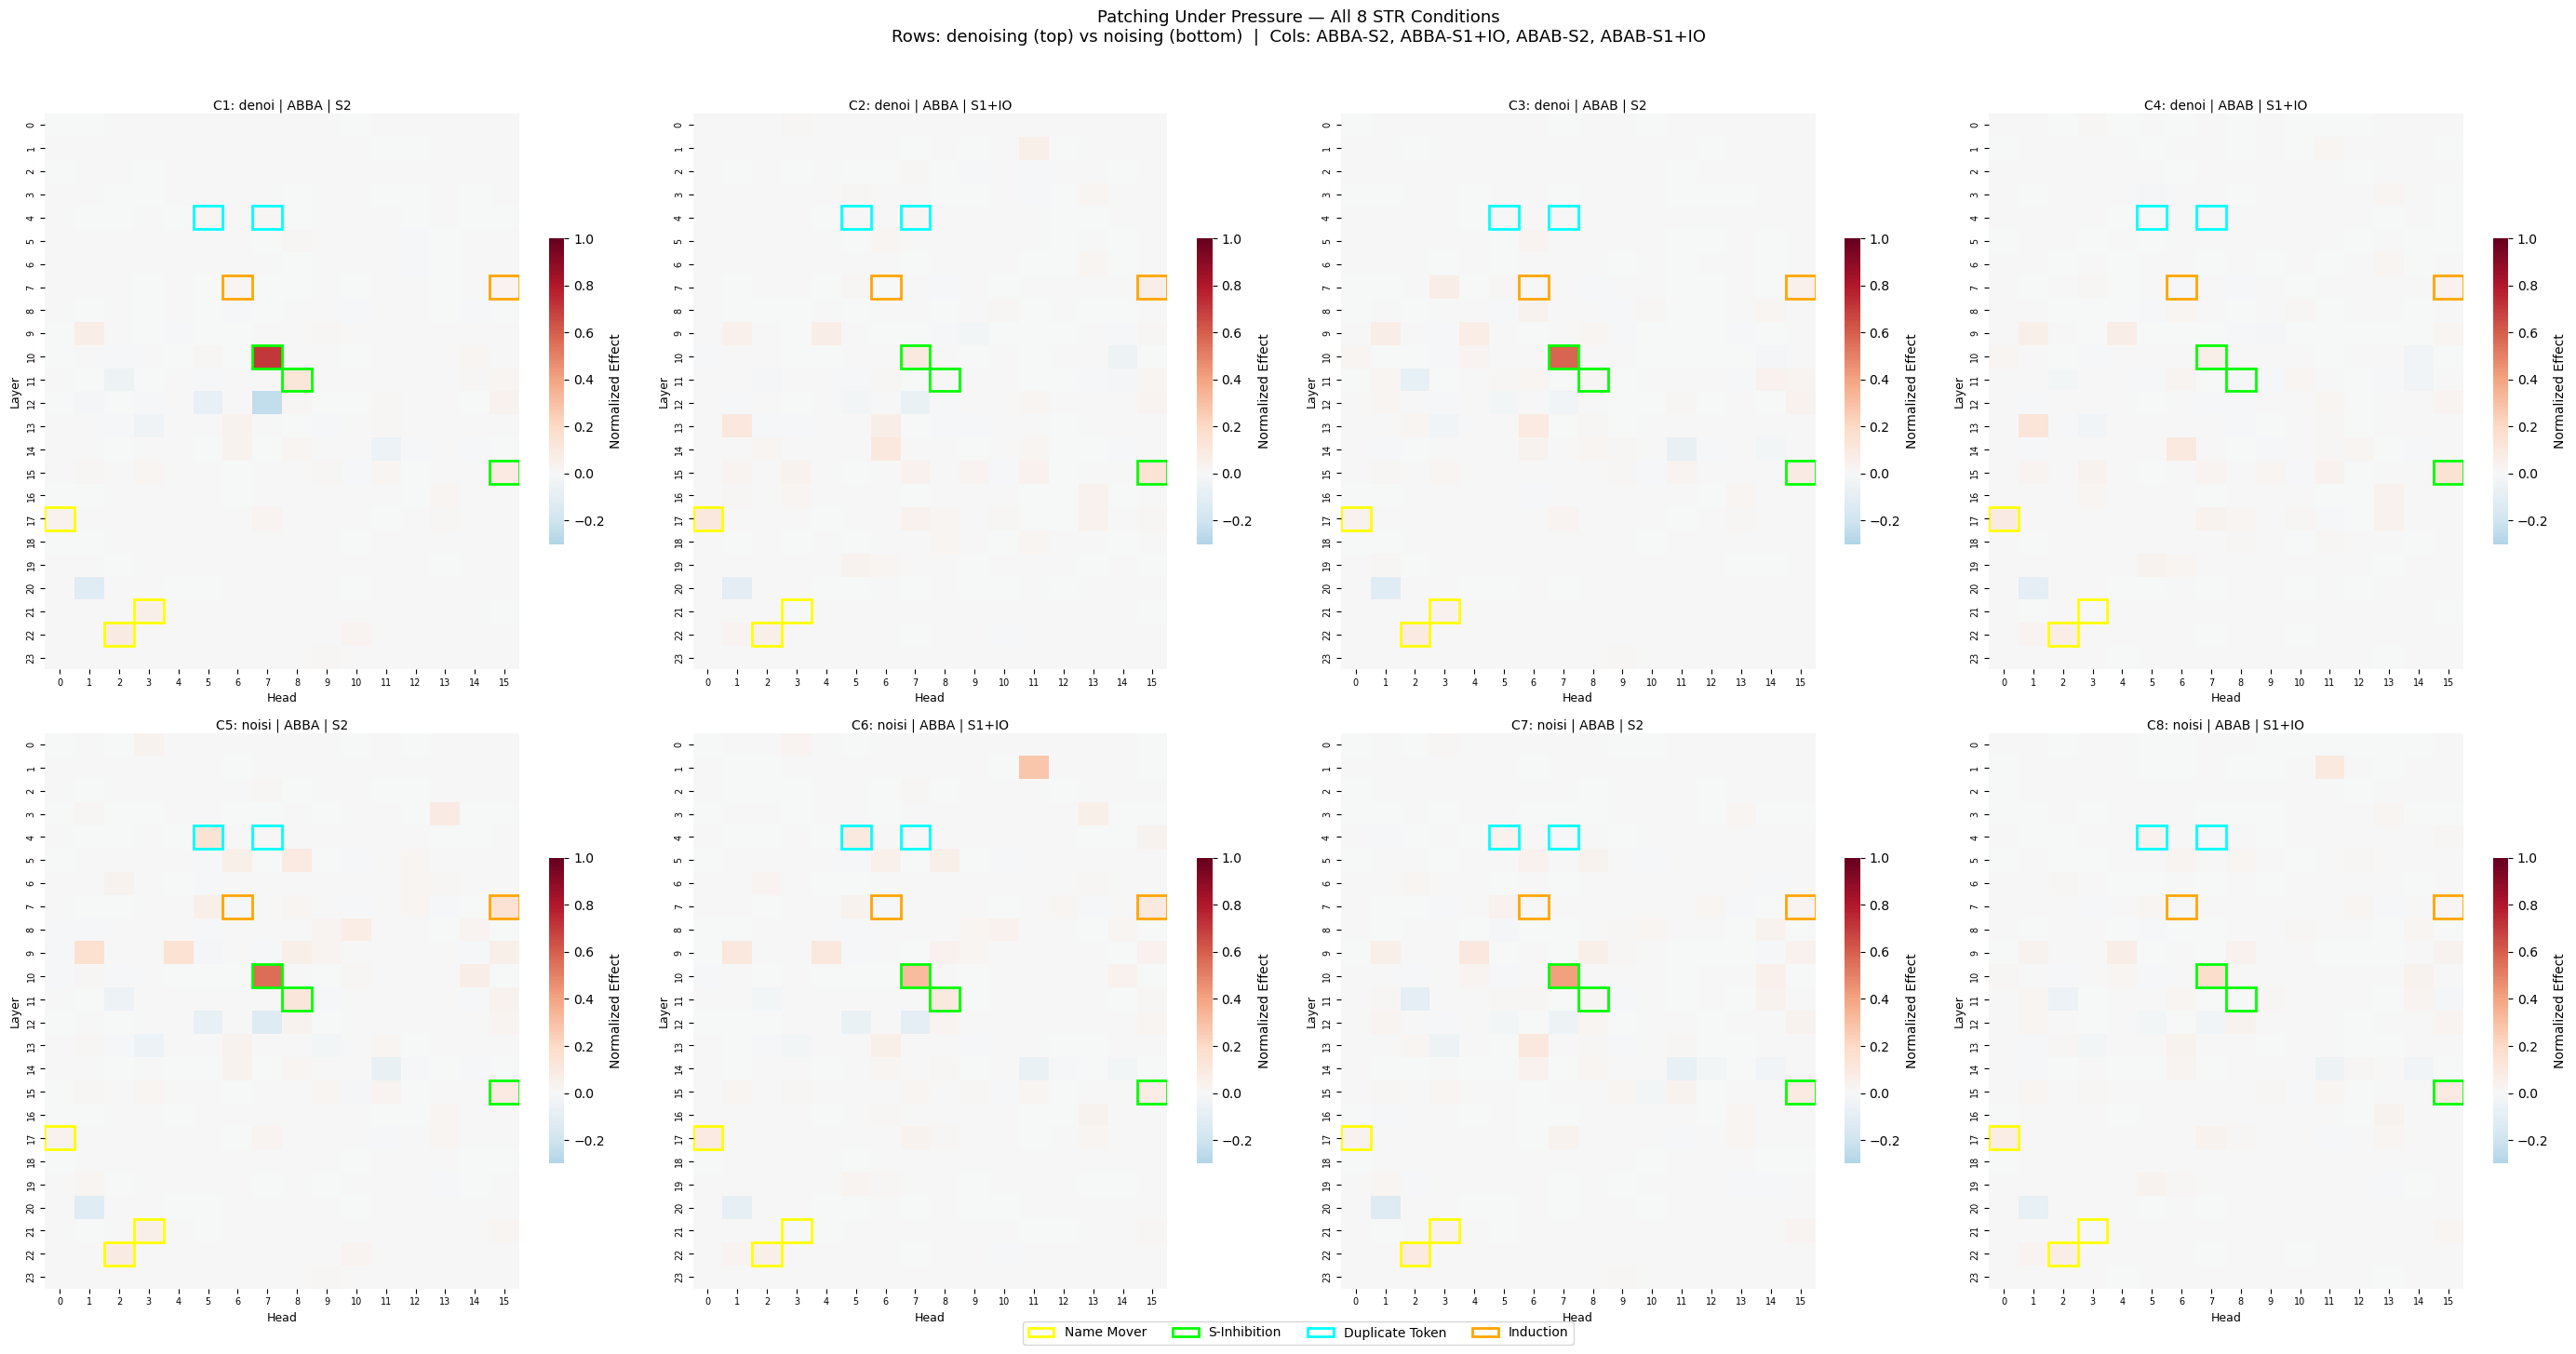

Saved → heatmaps_all_conditions.png


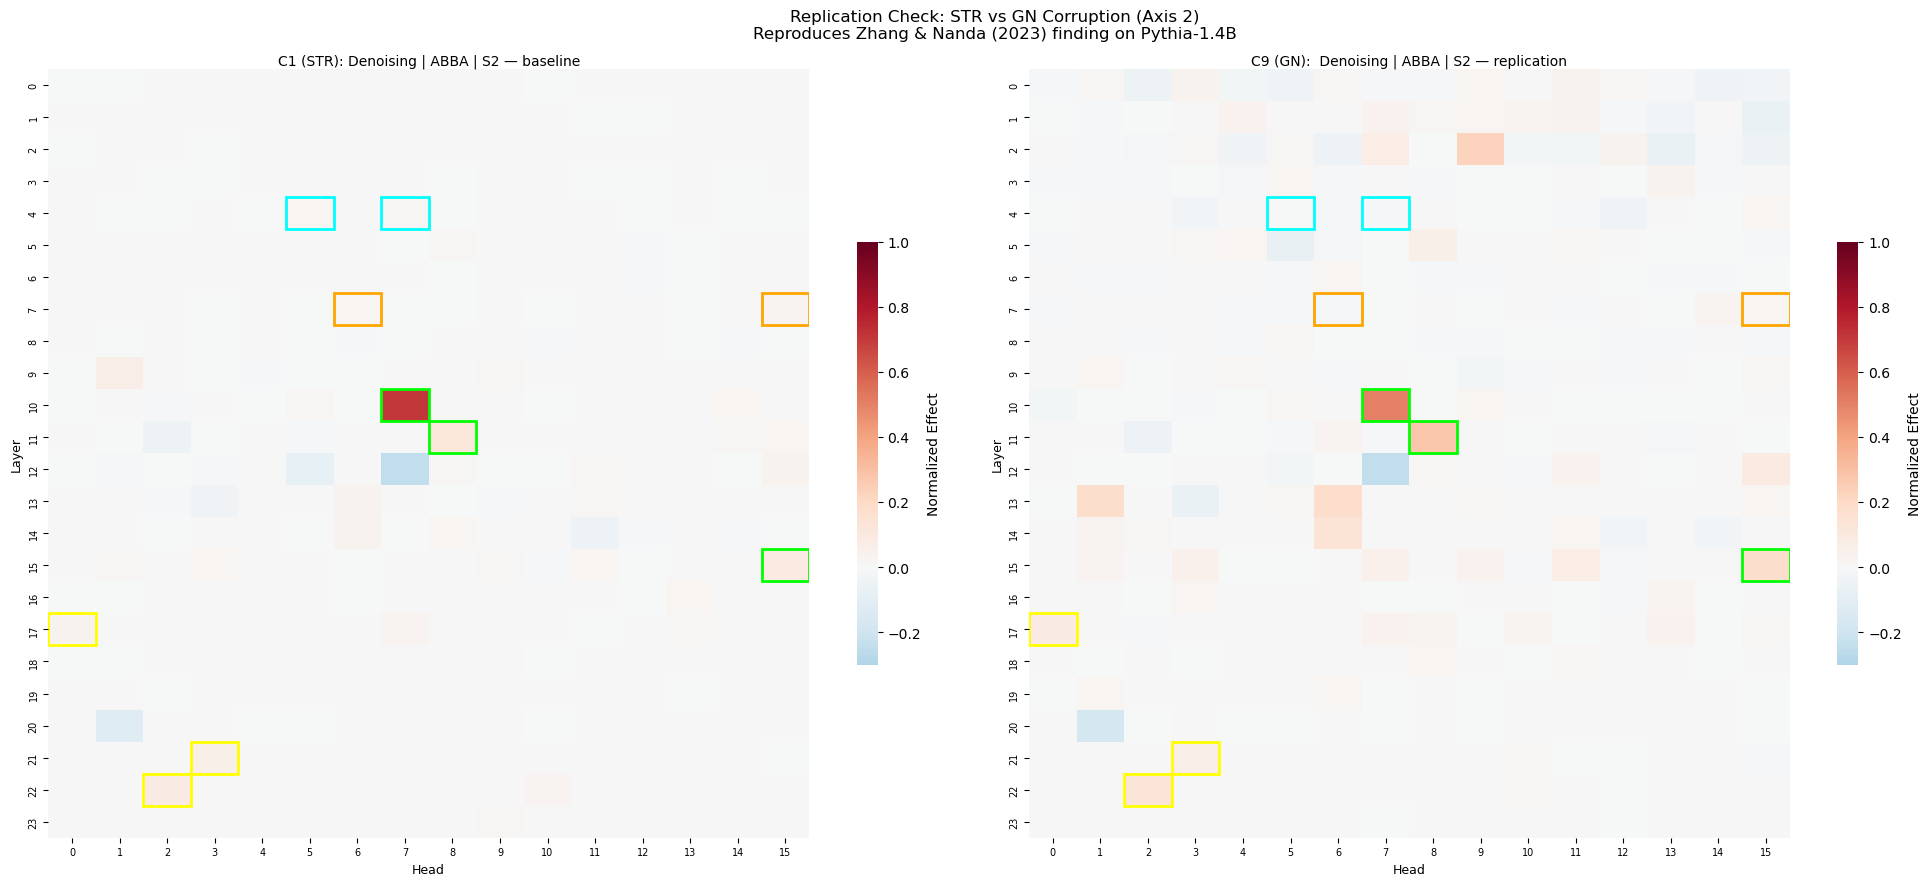

Saved → replication_str_vs_gn.png


In [24]:
"""
Cell 12: Patching effect heatmaps (proposal §4, Fig. 1).

Each cell shows the normalized patching effect for one (layer, head) pair.
Colored boxes mark known IOI circuit heads:
  Yellow = Name Mover  |  Lime = S-Inhibition
  Cyan = Duplicate Token  |  Orange = Induction

Red = high positive effect (important head)
Blue = negative effect (patching hurts)
White = no effect
"""

def plot_heatmap(effects: torch.Tensor, title: str, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 8))

    data = effects.detach().cpu().float().numpy()
    sns.heatmap(
        data, ax=ax, cmap="RdBu_r", center=0, vmin=-0.3, vmax=1.0,
        xticklabels=range(N_HEADS), yticklabels=range(N_LAYERS),
        linewidths=0, cbar_kws={"label": "Normalized Effect", "shrink": 0.55},
    )
    ax.set_xlabel("Head", fontsize=9)
    ax.set_ylabel("Layer", fontsize=9)
    ax.set_title(title, fontsize=10, pad=3)
    ax.tick_params(labelsize=7)

    for comp, heads in KNOWN_CIRCUIT.items():
        for (l, h) in heads:
            if l < N_LAYERS and h < N_HEADS:
                ax.add_patch(plt.Rectangle(
                    (h, l), 1, 1, fill=False,
                    edgecolor=COMP_COLORS[comp], lw=2.0
                ))

    if standalone:
        legend_patches = [
            mpatches.Patch(edgecolor=c, facecolor="none", lw=2, label=k)
            for k, c in COMP_COLORS.items()
        ]
        ax.legend(handles=legend_patches, loc="upper right", fontsize=8)
        plt.tight_layout()
        plt.show()


# 2×4 grid: all 8 STR conditions
str_cids = [c[0] for c in CONDITIONS[:8] if c[0] in effects_by_cid]
fig, axes = plt.subplots(2, 4, figsize=(28, 14))
for i, cid in enumerate(str_cids):
    c     = next(c for c in CONDITIONS if c[0] == cid)
    title = f"C{cid}: {c[1][:5]} | {c[2]} | {c[3]}"
    plot_heatmap(effects_by_cid[cid], title, ax=axes.flatten()[i])

legend_patches = [
    mpatches.Patch(edgecolor=c, facecolor="none", lw=2, label=k)
    for k, c in COMP_COLORS.items()
]
fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    "Patching Under Pressure — All 8 STR Conditions\n"
    "Rows: denoising (top) vs noising (bottom)  |  "
    "Cols: ABBA-S2, ABBA-S1+IO, ABAB-S2, ABAB-S1+IO",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("heatmaps_all_conditions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → heatmaps_all_conditions.png")

# STR vs GN comparison (replication check)
if 1 in effects_by_cid and 9 in effects_by_cid:
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    plot_heatmap(effects_by_cid[1],
                 "C1 (STR): Denoising | ABBA | S2 — baseline", ax=axes[0])
    plot_heatmap(effects_by_cid[9],
                 "C9 (GN):  Denoising | ABBA | S2 — replication", ax=axes[1])
    fig.suptitle(
        "Replication Check: STR vs GN Corruption (Axis 2)\n"
        "Reproduces Zhang & Nanda (2023) finding on Pythia-1.4B",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig("replication_str_vs_gn.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → replication_str_vs_gn.png")

In [25]:
"""
Cell 13: Axis-by-axis sensitivity analysis (proposal §4).

For each axis, compares detection scores across the two conditions
that differ only on that axis (all other variables held constant).

Also reports:
  - Jaccard similarity matrix (graded comparison, level c)
  - Threshold sensitivity sweep (1.5, 2.0, 2.5, 3.0 SD)
  - STR vs GN replication result

Interpretation guide:
  ✓ consistent = researchers can freely choose either option
  ✗ VARIES     = choice matters; must be specified and justified
  Jaccard < 0.5 = meaningfully different circuits discovered
"""
df_str = df[df["Corruption"] == "STR"]


def print_axis_summary(df: pd.DataFrame, axis_col: str, axis_vals: list):
    print(f"\n── Axis: {axis_col} ──")
    print(f"   Hypothesis tested: see proposal §3.3")
    for col in comp_cols:
        row = {v: df[df[axis_col] == v][col].tolist() for v in axis_vals}
        all_vals   = [x for xs in row.values() for x in xs]
        consistent = len(set(all_vals)) == 1
        status     = "✓ consistent" if consistent else "✗ VARIES"
        detail     = "  |  ".join(f"{k} → {v}" for k, v in row.items())
        print(f"  {col:<20}: {detail}   [{status}]")


print("═"*72)
print("AXIS-BY-AXIS SENSITIVITY ANALYSIS")
print("Primary comparison grain: relaxed (component-type detection score)")
print("═"*72)

print_axis_summary(df_str, "Direction",       ["denoising", "noising"])
print_axis_summary(df_str, "Template",        ["ABBA",      "ABAB"])
print_axis_summary(df_str, "Token Corrupted", ["S2",        "S1+IO"])

if 1 in effects_by_cid and 9 in effects_by_cid:
    print("\n── Replication: STR vs GN (Axis 2, Condition 1 vs 9) ──")
    c1 = df[df["Cond"] == 1].iloc[0]
    c9 = df[df["Cond"] == 9].iloc[0]
    for col in comp_cols:
        status = "✓ same" if c1[col] == c9[col] else "✗ DIFFERENT"
        print(f"  {col:<20}: STR={c1[col]}  GN={c9[col]}   [{status}]")

# ── Jaccard similarity matrix ─────────────────────────────────────────────
print("\n── Jaccard Similarity Matrix (graded comparison, level c) ──")
print("   Values < 0.5 indicate meaningfully different circuits")
cids    = sorted(effects_by_cid.keys())
jac_mat = pd.DataFrame(index=cids, columns=cids, dtype=float)
for ci in cids:
    for cj in cids:
        jac_mat.loc[ci, cj] = round(
            jaccard(detected_by_cid[ci], detected_by_cid[cj]), 2
        )
print(jac_mat.to_string())
jac_mat.to_csv("jaccard_similarity.csv")
print("Saved → jaccard_similarity.csv")

# ── Threshold sensitivity ─────────────────────────────────────────────────
print("\n── Threshold Sensitivity (proposal §3.2) ──")
print("   Stable across all thresholds = robust finding")
df_thresh = run_threshold_sensitivity(effects_by_cid)
for cid in [1, 5]:
    if cid in effects_by_cid:
        sub = df_thresh[df_thresh["Cond"] == cid][
            ["Threshold (nSD)"] + comp_cols
        ]
        print(f"\n  Condition {cid} ({['denoising','noising'][cid > 4]}):")
        print(sub.to_string(index=False))
df_thresh.to_csv("threshold_sensitivity.csv", index=False)
print("\nSaved → threshold_sensitivity.csv")

════════════════════════════════════════════════════════════════════════
AXIS-BY-AXIS SENSITIVITY ANALYSIS
Primary comparison grain: relaxed (component-type detection score)
════════════════════════════════════════════════════════════════════════

── Axis: Direction ──
   Hypothesis tested: see proposal §3.3
  Name Mover          : denoising → ['1/3', '2/3', '1/3', '2/3']  |  noising → ['1/3', '2/3', '1/3', '2/3']   [✗ VARIES]
  S-Inhibition        : denoising → ['3/3', '2/3', '2/3', '2/3']  |  noising → ['3/3', '3/3', '2/3', '2/3']   [✗ VARIES]
  Duplicate Token     : denoising → ['0/2', '0/2', '0/2', '0/2']  |  noising → ['1/2', '1/2', '0/2', '0/2']   [✗ VARIES]
  Induction           : denoising → ['0/2', '1/2', '0/2', '1/2']  |  noising → ['1/2', '1/2', '0/2', '0/2']   [✗ VARIES]

── Axis: Template ──
   Hypothesis tested: see proposal §3.3
  Name Mover          : ABBA → ['1/3', '2/3', '1/3', '2/3']  |  ABAB → ['1/3', '2/3', '1/3', '2/3']   [✗ VARIES]
  S-Inhibition        : ABBA → 

In [26]:
"""
Cell 14: Final recommendations and save all outputs.

Fill in the recommendations below after reviewing the detection tables.
These become the actionable conclusions of the paper (proposal §4).
"""
print("═"*72)
print("RECOMMENDATIONS (fill in after reviewing tables above)")
print("═"*72)
print()
print("Axis 1 — Direction (denoising vs noising):   [consistent / VARIES]")
print("Axis 2 — Corruption (STR vs GN):             [consistent / VARIES]")
print("Axis 3 — Template (ABBA vs ABAB):            [consistent / VARIES]")
print("Axis 4 — Token Corrupted (S2 vs S1+IO):      [consistent / VARIES]")
print()
print("Choices researchers must always specify:  ?")
print("Choices that are safe to pick freely:     ?")
print()

# Save all effects
torch.save(effects_by_cid, "effects_all_conditions.pt")
df.to_csv("detection_results.csv", index=False)

print("Output files:")
print("  detection_results.csv        ← main results table")
print("  jaccard_similarity.csv       ← graded comparison")
print("  threshold_sensitivity.csv    ← robustness check")
print("  heatmaps_all_conditions.png  ← Fig. 1")
print("  replication_str_vs_gn.png    ← Fig. 2")
print("  effects_all_conditions.pt    ← raw tensors for further analysis")
print("  checkpoints/effects_cN.pt    ← per-condition checkpoints")
print()
print("Done ✓")

════════════════════════════════════════════════════════════════════════
RECOMMENDATIONS (fill in after reviewing tables above)
════════════════════════════════════════════════════════════════════════

Axis 1 — Direction (denoising vs noising):   [consistent / VARIES]
Axis 2 — Corruption (STR vs GN):             [consistent / VARIES]
Axis 3 — Template (ABBA vs ABAB):            [consistent / VARIES]
Axis 4 — Token Corrupted (S2 vs S1+IO):      [consistent / VARIES]

Choices researchers must always specify:  ?
Choices that are safe to pick freely:     ?

Output files:
  detection_results.csv        ← main results table
  jaccard_similarity.csv       ← graded comparison
  threshold_sensitivity.csv    ← robustness check
  heatmaps_all_conditions.png  ← Fig. 1
  replication_str_vs_gn.png    ← Fig. 2
  effects_all_conditions.pt    ← raw tensors for further analysis
  checkpoints/effects_cN.pt    ← per-condition checkpoints

Done ✓
